# Paper 2 — Cross-Site Transferability of the Arrival-Driven Charging Calibration
## (Caltech ACN ⇄ NYC DOT municipal charging, + optional JPL/office sites)

**Aligned to the completed Paper 1 v3 run.** This notebook consumes Paper 1's actual outputs:
- `results/table_physics_function_coefficients_v2.csv` (models `caltech_conditional`, `caltech_forecast`)
- `data_acn/acn_hourly_calib.csv` (143-day hourly target, tz-aware UTC timestamps)

Copy Paper 1's `results/` and `data_acn/` folders into this working directory before running Section 4+.

**Timezone correction (important, new in this version).** Paper 1's cached ACN timestamps are UTC; hour-of-day features there are therefore UTC-phase. For a *single* site this only shifts the phase of `hour_sin/cos` and changes no metric. For *cross-site* comparison it would misalign hour-of-week climatology by the 3-h difference between Pacific and Eastern time. This notebook therefore converts each site to **its own local time** (Caltech → America/Los_Angeles, NYC → America/New_York) before deriving hour/day-of-week, and **re-fits the Caltech calibration in local time** from the shipped cache. Expect the Caltech local-time R² to match Paper 1's (~0.82) with `hour_sin/cos` phases rotated; the arrival-dominance shares should be essentially unchanged — verify and report both.

**Design.** (1) Independent NYC calibration under the *identical* v3 specification. (2) Test A: coefficient-structure comparison via shares of absolute coefficient mass. (3) Test B: frozen-model bidirectional transfer, separating raw-scale R² from shape (pattern) R². (4) Optional: repeat for ACN `jpl` and `office001` sites for a 4-site map (matches the funding proposal's Task 3).

**Prespecified honesty rule:** both outcomes (transfers / population-dependent) are publishable; write whichever the numbers show. All API keys below are placeholders.

## 1. Setup

In [26]:
import os, numpy as np, pandas as pd, requests
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
rng = np.random.default_rng(SEED)

SITE_TZ = {"caltech": "America/Los_Angeles", "jpl": "America/Los_Angeles",
           "office001": "America/Los_Angeles", "nyc": "America/New_York"}

NYC_TEST_FRACTION = 0.2
ACN_API_TOKEN = "ysNyZacnk5TSiR6GHDFMavDSmHM4WSUcbpGMXf_qQ_k"           # for optional JPL/office fetch
OPENCHARGEMAP_API_KEY = "67ad417d-e49a-4744-ae90-d594ee1e6e43"     # for NYC charger context (optional)

for d in ["data_nyc", "results_p2", "figures_p2"]:
    os.makedirs(d, exist_ok=True)

In [27]:
# Vehicle-class road-load parameters (identical to Paper 1)
OPENCHARGEMAP_API_KEY = "PASTE_YOUR_OCM_KEY_HERE"  # your real key
NYC_STUDY_PLACE = "Manhattan, New York, USA"
NOISE_STD_FRACTION = 0.08
VEHICLE_PARAMS = {
    "passenger_ev": {"mass_kg": 1900, "Cd": 0.28, "area_m2": 2.4, "Crr": 0.010, "eta_drive": 0.88, "aux_kw": 0.8},
    "transit_bus_ev": {"mass_kg": 14500, "Cd": 0.65, "area_m2": 8.0, "Crr": 0.009, "eta_drive": 0.86, "aux_kw": 3.0},
    "freight_ev": {"mass_kg": 30000, "Cd": 0.60, "area_m2": 10.0, "Crr": 0.007, "eta_drive": 0.84, "aux_kw": 4.0},
}
CHARGER_EFFICIENCY = {"home": 0.900, "depot": 0.920, "corridor": 0.930}
SEED = 42
rng = np.random.default_rng(SEED)

# Functions 15.4 reuses from earlier sections
def road_load_energy_kwh_per_mile(speed_mph, grade, accel_mps2, vehicle_class):
    p = VEHICLE_PARAMS[vehicle_class]
    v = float(speed_mph) * 0.44704
    grade = float(grade)
    theta = np.arctan(grade)
    drag = 0.5 * 1.225 * p["Cd"] * p["area_m2"] * v ** 2
    rolling = p["Crr"] * p["mass_kg"] * 9.81 * np.cos(theta)
    grade_force = p["mass_kg"] * 9.81 * np.sin(theta)
    force_sum = max(0.0, drag + rolling + grade_force + p["mass_kg"] * accel_mps2)
    return (1609.344 / (3.6e6 * p["eta_drive"])) * force_sum

def assign_context(functional_class):
    return {"freeway": "corridor", "arterial": "corridor",
            "collector": "depot", "local": "home"}.get(functional_class, "home")

from sklearn.preprocessing import StandardScaler
import os
os.makedirs("results_nyc", exist_ok=True)
print("Variables ready for 15.4")

Variables ready for 15.4


## 2. The identical calibration specification (verbatim from Paper 1 v3)

Do not modify — cross-site comparability requires identity of specification.

In [28]:
def fit_physics_function(h, n_train_days, label, results_dir="results_p2"):
    """Identical to Paper 1 v3 Section 9B: train-only normalization, ridge LOO-CV,
    conditional + forecast-feasible variants."""
    h = h.sort_values(["day", "hour"]).reset_index(drop=True)
    days = sorted(h["day"].unique())
    tr_mask = h["day"].isin(days[:n_train_days]).values
    te_mask = ~tr_mask
    eps = 1e-9
    trd = h.loc[tr_mask]
    h = h.copy()
    h["E_phys_norm"]   = h["E_phys_raw_kwh"] / max(trd["E_phys_raw_kwh"].max(), eps)
    h["sessions_norm"] = h["n_sessions"]     / max(trd["n_sessions"].max(), eps)
    h["E_per_session_pressure"] = h["E_phys_raw_kwh"] / np.maximum(h["n_sessions"], 1)
    h["E_per_session_pressure_norm"] = (h["E_per_session_pressure"] /
        max(h.loc[tr_mask, "E_per_session_pressure"].max(), eps))
    h["hour_sin"] = np.sin(2*np.pi*h["hour"]/24); h["hour_cos"] = np.cos(2*np.pi*h["hour"]/24)
    h["session_hour_sin"] = h["sessions_norm"]*h["hour_sin"]
    h["session_hour_cos"] = h["sessions_norm"]*h["hour_cos"]
    for lag in [1,2,3,6,12,24]:
        h[f"E_phys_lag_{lag}h"] = h["E_phys_norm"].shift(lag).fillna(0.0)
    for w in [3,6,24]:
        h[f"E_phys_roll_{w}h"] = h["E_phys_norm"].rolling(w, min_periods=1).mean()
    h["sessions_lag_24h"]  = h["sessions_norm"].shift(24).fillna(0.0)
    h["sessions_lag_168h"] = h["sessions_norm"].shift(168).fillna(0.0)
    how = h["dow"]*24 + h["hour"]
    clim = h.loc[tr_mask].assign(how=how[tr_mask]).groupby("how")["sessions_norm"].mean()
    h["sessions_climatology"] = how.map(clim).fillna(clim.mean())

    feats_cond = ["sessions_norm","E_phys_norm","E_per_session_pressure_norm",
                  "hour_sin","hour_cos","session_hour_sin","session_hour_cos","is_weekend",
                  "E_phys_lag_1h","E_phys_lag_2h","E_phys_lag_3h","E_phys_lag_6h",
                  "E_phys_lag_12h","E_phys_lag_24h","E_phys_roll_3h","E_phys_roll_6h","E_phys_roll_24h"]
    feats_fcst = ["sessions_lag_24h","sessions_lag_168h","sessions_climatology",
                  "E_phys_norm","hour_sin","hour_cos","is_weekend",
                  "E_phys_lag_1h","E_phys_lag_24h","E_phys_roll_24h"]
    y = h["real_load_kwh"].values
    metrics, coefs, models = [], [], {}
    for feats, name in [(feats_cond, f"{label}_conditional"), (feats_fcst, f"{label}_forecast")]:
        X = h[feats].values
        m = RidgeCV(alphas=np.logspace(-4, 4, 25), fit_intercept=True)
        m.fit(X[tr_mask], y[tr_mask])
        pred = np.clip(m.predict(X), 0, None)
        for split, mask in [("train", tr_mask), ("test", te_mask)]:
            yt, yp = y[mask], pred[mask]; nz = yt > 1e-6
            metrics.append({"model": name, "split": split,
                "RMSE_kWh": float(np.sqrt(mean_squared_error(yt, yp))),
                "MAE_kWh": float(mean_absolute_error(yt, yp)),
                "R2": float(r2_score(yt, yp)),
                "MAPE_pct_nonzero": float(np.mean(np.abs((yt[nz]-yp[nz])/yt[nz]))*100) if nz.sum() else np.nan})
        cdf = pd.DataFrame({"feature": feats, "coefficient": m.coef_})
        cdf.loc[len(cdf)] = ["intercept", m.intercept_]
        cdf["model"] = name; cdf["ridge_alpha"] = m.alpha_
        coefs.append(cdf); models[name] = (m, feats)
    mdf, cdf = pd.DataFrame(metrics), pd.concat(coefs, ignore_index=True)
    mdf.to_csv(f"{results_dir}/physics_function_metrics_{label}.csv", index=False)
    cdf.to_csv(f"{results_dir}/physics_function_coefficients_{label}.csv", index=False)
    return h, models, tr_mask, te_mask, mdf, cdf

def prepare_site_hourly(df, tz, load_col="real_load_kwh"):
    """timestamp_hour (any tz) -> local-time day/hour/dow frame on a dense hourly index."""
    d = df.copy()
    d["timestamp_hour"] = pd.to_datetime(d["timestamp_hour"], utc=True).dt.tz_convert(tz).dt.tz_localize(None)
    # DST fall-back creates a duplicated wall-clock hour (e.g., 2019-11-03 01:00 in the US);
    # aggregate duplicates: energy and arrivals from both UTC hours genuinely belong to
    # that local hour, so summing is the physically correct resolution.
    d = (d.groupby("timestamp_hour", as_index=False)
           .agg(**{load_col: (load_col, "sum"), "n_sessions": ("n_sessions", "sum")}))
    d = (d.set_index("timestamp_hour")
           .reindex(pd.date_range(d["timestamp_hour"].min(), d["timestamp_hour"].max(), freq="h"))
           .rename_axis("timestamp_hour").reset_index())
    d[load_col] = d[load_col].fillna(0.0)
    d["n_sessions"] = d["n_sessions"].fillna(0).astype(int)
    day0 = d["timestamp_hour"].dt.normalize().min()
    d["day"]  = (d["timestamp_hour"].dt.normalize() - day0).dt.days
    d["hour"] = d["timestamp_hour"].dt.hour
    d["dow"]  = d["timestamp_hour"].dt.dayofweek
    d["is_weekend"] = (d["dow"] >= 5).astype(int)
    return d

## 3. Caltech source calibration, re-fit in local time

Uses Paper 1's shipped 143-day cache; E_phys tiled from Paper 1's processed table's (dow, hour) profile.

In [29]:
h_cal_raw = pd.read_csv("data_acn/acn_hourly_calib.csv")
h_cal = prepare_site_hourly(h_cal_raw, SITE_TZ["caltech"])

# E_phys weekly profile from Paper 1's processed table (UTC-phase there; re-key to
# local (dow,hour) by rebuilding from the same raw values after tz conversion is
# not possible for E_phys itself, so tile Paper 1's profile shifted to local time).
p1 = pd.read_csv("results/hourly_acn_calibrated_physics_function_v2.csv")
prof_utc = p1.groupby(["dow", "hour"])["E_phys_raw_kwh"].mean()
# shift the UTC-phased weekly profile to LA local (UTC-8 standard; window is winter)
UTC_OFFSET_H = -8
idx = pd.MultiIndex.from_product([range(7), range(24)], names=["dow", "hour"])
shifted = {}
for dow, hr in idx:
    total = (dow*24 + hr - UTC_OFFSET_H) % (7*24)
    shifted[(dow, hr)] = prof_utc.get((total // 24, total % 24), prof_utc.mean())
h_cal["E_phys_raw_kwh"] = pd.MultiIndex.from_frame(h_cal[["dow","hour"]]).map(pd.Series(shifted))

n_days_cal = h_cal["day"].nunique()
CAL_TEST = max(7, int(round(n_days_cal*0.2)))
h_cal_fit, models_cal, tr_cal, te_cal, m_cal, c_cal = fit_physics_function(
    h_cal, n_days_cal-CAL_TEST, "caltech_local")
print("Caltech local-time refit (compare to Paper 1: test R2 ~0.82):")
display(m_cal)

Caltech local-time refit (compare to Paper 1: test R2 ~0.82):


,model,split,RMSE_kWh,MAE_kWh,R2,MAPE_pct_nonzero
0,caltech_local_conditional,train,9.492933,4.223018,0.802973,157.350685
1,caltech_local_conditional,test,8.740145,4.437391,0.815627,199.195746
2,caltech_local_forecast,train,13.933104,7.098254,0.575557,150.948293
3,caltech_local_forecast,test,12.274864,6.510444,0.636342,194.826814


## 4. NYC real data

### 4.1 Road network + grade (optional; enables real E_phys — fallback exists)

In [30]:
NYC_STUDY_PLACE = "Manhattan, New York, USA"
STUDY_PLACE = NYC_STUDY_PLACE
NETWORK_TYPE = "drive"
GRADE_RESOLUTION_M = 30
REAL_DATA_ONLY = True
SEED = 42

print(STUDY_PLACE, NETWORK_TYPE, GRADE_RESOLUTION_M, REAL_DATA_ONLY)

Manhattan, New York, USA drive 30 True


In [31]:
import osmnx as ox
import networkx as nx

def fetch_network(place=STUDY_PLACE, network_type=NETWORK_TYPE):
    print(f"Downloading OSM road network for: {place}")
    G = ox.graph_from_place(place, network_type=network_type)
    G = ox.add_edge_speeds(G)
    G = ox.add_edge_travel_times(G)

    print("Computing node betweenness centrality from the real street network "
          "(used later to shape congestion realistically instead of a uniform assumption)...")
    Gs = nx.DiGraph(G)  # collapse parallel edges for a tractable centrality approximation
    k = min(200, Gs.number_of_nodes())
    node_centrality = nx.betweenness_centrality(Gs, k=k, weight="length", seed=SEED)

    edges = ox.graph_to_gdfs(G, nodes=False).reset_index()
    edges["link_id"] = edges["u"].astype(str) + "_" + edges["v"].astype(str) + "_" + edges["key"].astype(str)
    edges["centrality"] = 0.5 * (edges["u"].map(node_centrality).fillna(0)
                                  + edges["v"].map(node_centrality).fillna(0))

    keep = ["link_id", "length", "speed_kph", "highway", "centrality", "geometry"]
    edges = edges[[c for c in keep if c in edges.columns]].copy()
    edges["length_mi"] = edges["length"] / 1609.344

    def functional_class(hwy):
        if isinstance(hwy, list):
            hwy = hwy[0]
        hwy = str(hwy)
        if "motorway" in hwy or "trunk" in hwy:
            return "freeway"
        if "primary" in hwy:
            return "arterial"
        if "secondary" in hwy or "tertiary" in hwy:
            return "collector"
        return "local"

    edges["functional_class"] = edges["highway"].apply(functional_class)
    cmax = edges["centrality"].max()
    edges["centrality_norm"] = edges["centrality"] / cmax if cmax > 0 else 0.0
    return edges

edges = fetch_network()
edges.to_file("data_nyc/road_links.geojson", driver="GeoJSON")
print(f"Saved {len(edges)} links")
edges.head()


Computing node betweenness centrality from the real street network (used later to shape congestion realistically instead of a uniform assumption)...
Saved 9915 links


,link_id,length,speed_kph,highway,centrality,geometry,length_mi,functional_class,centrality_norm
0,42421728_42435337_0,85.345155,40.233500,secondary,0.035828,"LINESTRING (-73.96004 40.79805, -73.96011 40.7...",0.053031,collector,0.250507
1,42421728_42421731_0,138.033090,38.915427,secondary,0.033728,"LINESTRING (-73.96004 40.79805, -73.96017 40.7...",0.085770,collector,0.235824
2,42421728_42432736_0,86.274316,40.233500,secondary,0.035707,"LINESTRING (-73.96004 40.79805, -73.95997 40.7...",0.053608,collector,0.249661
3,42421731_42437916_0,86.149203,37.694143,residential,0.018438,"LINESTRING (-73.96147 40.79865, -73.96154 40.7...",0.053531,local,0.128917
4,42421731_42432737_0,85.968765,37.694143,residential,0.031734,"LINESTRING (-73.96147 40.79865, -73.9614 40.79...",0.053419,local,0.221886


In [32]:
import geopandas as gpd
import py3dep

def add_grade(edges, resolution=GRADE_RESOLUTION_M):
    edges = edges.to_crs(4326)
    starts = edges.geometry.apply(lambda g: g.coords[0])
    ends = edges.geometry.apply(lambda g: g.coords[-1])
    coords_df = pd.DataFrame({
        "x": pd.concat([starts.apply(lambda c: c[0]), ends.apply(lambda c: c[0])], ignore_index=True),
        "y": pd.concat([starts.apply(lambda c: c[1]), ends.apply(lambda c: c[1])], ignore_index=True),
    })
    print(f"Querying USGS 3DEP elevation for {len(coords_df)} points (resolution={resolution} m)...")
    elev = py3dep.elevation_bycoords(list(zip(coords_df.x, coords_df.y)), crs=4326)
    n = len(edges)
    elev_start = np.array(elev[:n])
    elev_end = np.array(elev[n:])
    rise = elev_end - elev_start
    run_m = np.where(edges["length"].values.astype(float) == 0, 1e-6, edges["length"].values.astype(float))
    grade = np.clip(rise / run_m, -0.12, 0.12)

    edges = edges.copy()
    edges["elev_start_m"] = elev_start
    edges["elev_end_m"] = elev_end
    edges["grade"] = grade
    edges["grade_pct"] = grade * 100
    # Link centroid, needed downstream to spatially match links to real charger
    # locations (Open Charge Map) instead of guessing context from road class alone.
    centroids = edges.geometry.centroid
    edges["centroid_lon"] = centroids.x
    edges["centroid_lat"] = centroids.y
    return edges

edges_grade = add_grade(gpd.read_file("data_nyc/road_links.geojson"))
edges_grade.drop(columns="geometry").to_csv("data_nyc/road_links_grade.csv", index=False)
edges_grade[["link_id", "grade_pct"]].describe()


Querying USGS 3DEP elevation for 19830 points (resolution=30 m)...


C:\Users\schowdho\AppData\Local\Temp\ipykernel_39272\1466923218.py:28: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = edges.geometry.centroid


,grade_pct
count,9915.000000
mean,0.009763
std,2.186981
min,-12.000000
25%,-0.758698
50%,0.000054
75%,0.779471
max,12.000000


In [33]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

In [34]:
import os
NYC_STUDY_PLACE = "Manhattan, New York, USA"  # tractable size with strong real sensor coverage
os.makedirs("data_nyc", exist_ok=True)
os.makedirs("results_nyc", exist_ok=True)
os.makedirs("figures_nyc", exist_ok=True)

# --- 15.1 Real road network + grade for the NYC study area (reuses Section 2/3 functions) ---
nyc_edges = fetch_network(place=NYC_STUDY_PLACE, network_type=NETWORK_TYPE)
nyc_edges.to_file("data_nyc/road_links.geojson", driver="GeoJSON")
nyc_edges_grade = add_grade(gpd.read_file("data_nyc/road_links.geojson"))
nyc_edges_grade.drop(columns="geometry").to_csv("data_nyc/road_links_grade.csv", index=False)
print(f"NYC network: {len(nyc_edges_grade)} links.")


Computing node betweenness centrality from the real street network (used later to shape congestion realistically instead of a uniform assumption)...
Querying USGS 3DEP elevation for 19830 points (resolution=30 m)...


C:\Users\schowdho\AppData\Local\Temp\ipykernel_39272\1466923218.py:28: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = edges.geometry.centroid


NYC network: 9915 links.


### 4.2 NYC DOT continuous speeds (Socrata i4gi-tjb9)

In [35]:
# --- 15.2 Real NYC DOT continuous speed data (replaces the synthetic DANA-style fallback) ---
# FIXED after live 404: the correct dataset is "DOT Traffic Speeds NBE", resource
# i4gi-tjb9 on data.cityofnewyork.us (I previously had both the wrong resource ID and
# the wrong domain). Schema confirmed from NYC Open Data: id, speed, travel_time,
# status, data_as_of, link_id, link_points, encoded_poly_line, ..., borough, link_name.
NYC_SPEED_RESOURCE = "i4gi-tjb9"

def fetch_nyc_speed_history(resource=NYC_SPEED_RESOURCE, page_size=50000, max_pages=10):
    """Pages through recent records via Socrata $limit/$offset, most recent first.
    The full dataset is ~58M records back to 2017 -- max_pages=10 pulls the most recent
    ~500k readings, typically several recent days across all sensors, which is enough
    for the case study. Raise max_pages for a longer real window."""
    all_recs = []
    for page in range(max_pages):
        offset = page * page_size
        url = (f"https://data.cityofnewyork.us/resource/{resource}.json"
               f"?$limit={page_size}&$offset={offset}&$order=data_as_of%20DESC")
        try:
            batch = pd.read_json(url)
        except Exception as e:
            print(f"WARNING: NYC speed history fetch failed on page {page} ({e}).")
            break
        if batch.empty:
            break
        all_recs.append(batch)
        print(f"  fetched page {page}: {len(batch)} rows (offset {offset})")
        if len(batch) < page_size:
            break
    if not all_recs:
        return None
    return pd.concat(all_recs, ignore_index=True)

print(f"Downloading real NYC DOT speed history (resource {NYC_SPEED_RESOURCE})...")
nyc_speed_raw = fetch_nyc_speed_history()

if nyc_speed_raw is not None and len(nyc_speed_raw) > 0:
    print("Real NYC speed columns found:", nyc_speed_raw.columns.tolist())
    nyc_speed_raw.to_csv("data_nyc/nyc_speed_raw.csv", index=False)

    speed_col = next((c for c in nyc_speed_raw.columns if c.lower() == "speed"), None)
    time_col = next((c for c in nyc_speed_raw.columns if "data_as_of" in c.lower() or "asof" in c.lower()), None)
    points_col = next((c for c in nyc_speed_raw.columns if "link_points" in c.lower()), None)

    if speed_col and time_col and points_col:
        nyc_speed_raw[time_col] = pd.to_datetime(nyc_speed_raw[time_col], errors="coerce")
        nyc_speed_raw[speed_col] = pd.to_numeric(nyc_speed_raw[speed_col], errors="coerce")
        nyc_speed_raw = nyc_speed_raw.dropna(subset=[time_col, speed_col])
        real_days = nyc_speed_raw[time_col].dt.date.nunique()
        print(f"Real NYC speed data spans {real_days} distinct real day(s) "
              f"({nyc_speed_raw[time_col].min()} to {nyc_speed_raw[time_col].max()}).")

        def first_point(pts):
            try:
                first = str(pts).split(" ")[0]
                lat_s, lon_s = first.split(",")
                return float(lat_s), float(lon_s)
            except Exception:
                return None, None

        anchors = nyc_speed_raw[points_col].apply(first_point)
        nyc_speed_raw["sensor_lat"] = anchors.apply(lambda t: t[0])
        nyc_speed_raw["sensor_lon"] = anchors.apply(lambda t: t[1])
        nyc_speed_raw = nyc_speed_raw.dropna(subset=["sensor_lat", "sensor_lon"])

        nyc_links = pd.read_csv("data_nyc/road_links_grade.csv")
        nyc_speed_raw["day"] = (nyc_speed_raw[time_col].dt.date
                                 - nyc_speed_raw[time_col].dt.date.min()).apply(lambda d: d.days)
        nyc_speed_raw["hour"] = nyc_speed_raw[time_col].dt.hour

        link_lat = nyc_links["centroid_lat"].values
        link_lon = nyc_links["centroid_lon"].values
        sensor_unique = nyc_speed_raw.drop_duplicates(subset=["sensor_lat", "sensor_lon"])
        su_lat, su_lon = sensor_unique["sensor_lat"].values, sensor_unique["sensor_lon"].values
        print(f"{len(sensor_unique)} unique real sensor locations found.")

        nearest_sensor_idx = np.zeros(len(nyc_links), dtype=int)
        nearest_sensor_dist = np.zeros(len(nyc_links))
        for i in range(len(nyc_links)):
            d = haversine_km(link_lat[i], link_lon[i], su_lat, su_lon)
            nearest_sensor_idx[i] = np.argmin(d)
            nearest_sensor_dist[i] = d.min()

        # Only trust links within 1.5 km of a real sensor (sensors cover major arterials,
        # not every side street -- an honest coverage restriction, reported below).
        covered = nearest_sensor_dist <= 1.5
        print(f"{covered.sum()} / {len(nyc_links)} links are within 1.5 km of a real sensor.")

        sensor_series = {}
        for (slat, slon), g in nyc_speed_raw.groupby(["sensor_lat", "sensor_lon"]):
            sensor_series[(slat, slon)] = g.groupby(["day", "hour"], as_index=False)[speed_col].mean()

        rows = []
        for i in np.where(covered)[0]:
            key = (su_lat[nearest_sensor_idx[i]], su_lon[nearest_sensor_idx[i]])
            g = sensor_series.get(key)
            if g is None:
                continue
            link_id = nyc_links["link_id"].values[i]
            for _, r in g.iterrows():
                rows.append({"link_id": link_id, "day": int(r["day"]), "hour": int(r["hour"]),
                             "speed_mph": float(r[speed_col])})

        nyc_traffic = pd.DataFrame(rows)
        if len(nyc_traffic) > 0:
            link_max = nyc_traffic.groupby("link_id")["speed_mph"].transform("max")
            nyc_traffic["congestion_index"] = (1 - nyc_traffic["speed_mph"] / link_max.clip(lower=1)).clip(0, 1)
            nyc_traffic.to_csv("data_nyc/traffic_hourly.csv", index=False)
            print(f"Built REAL (not synthetic) NYC traffic table: {len(nyc_traffic)} rows, "
                  f"{nyc_traffic['link_id'].nunique()} links with real observations.")
        else:
            print("No link/sensor matches produced rows; NYC case study cannot proceed.")
            nyc_traffic = None
    else:
        print("Could not auto-detect speed/time/geometry columns; inspect columns above.")
        nyc_traffic = None
else:
    print("Real NYC speed fetch returned no data. NYC case study cannot proceed without it.")
    nyc_traffic = None


  fetched page 0: 50000 rows (offset 0)
  fetched page 1: 50000 rows (offset 50000)
  fetched page 2: 50000 rows (offset 100000)
  fetched page 3: 50000 rows (offset 150000)
  fetched page 4: 50000 rows (offset 200000)
  fetched page 5: 50000 rows (offset 250000)
  fetched page 6: 50000 rows (offset 300000)
  fetched page 7: 50000 rows (offset 350000)
  fetched page 8: 50000 rows (offset 400000)
  fetched page 9: 50000 rows (offset 450000)
Real NYC speed columns found: ['id', 'speed', 'travel_time', 'status', 'data_as_of', 'link_id', 'link_points', 'encoded_poly_line', 'encoded_poly_line_lvls', 'owner', 'transcom_id', 'borough', 'link_name']
Real NYC speed data spans 16 distinct real day(s) (2026-06-20 12:00:23 to 2026-07-05 10:45:13).
121 unique real sensor locations found.
7056 / 9915 links are within 1.5 km of a real sensor.
Built REAL (not synthetic) NYC traffic table: 2455488 rows, 7056 links with real observations.


### 4.3 NYC DOT EV charging sessions (real observed kWh; verified station addresses)

In [36]:
# --- 15.3 Real NYC EV charging usage (fixed: hardcoded real addresses from NYC DOT) ---
# Geocoding by station name failed because OSM can't resolve internal NYC DOT facility
# codes. Fixed with a hardcoded lookup table of verified real addresses from:
# https://www.nyc.gov/html/dot/html/motorist/parkinglist.shtml and NYC DOT EV reports.

NYC_EV_CHARGING_URL = "https://data.cityofnewyork.us/resource/kj7g-u4gp.json"

# Real verified addresses for all NYC DOT municipal EV charging stations
STATION_COORDS = {
    # Manhattan
    "Delancey and Essex Municipal Parking Garage":  (40.71823, -73.98733),  # 105-113 Essex St
    "DES - Delancey and Essex Municipal Parking Garage": (40.71823, -73.98733),
    # Queens
    "Court Square Municipal Parking Garage":         (40.74727, -73.94513),  # 45-40 Court Square
    "CSQ - Court Square Municipal Parking Garage":   (40.74727, -73.94513),
    "Queens Borough Hall Municipal Parking Garage":  (40.70780, -73.83026),  # 80-25 126th St, Kew Gardens
    "QBO - Queens Borough Hall Municipal Parking Garage": (40.70780, -73.83026),
    "Queens Family Court Municipal Garage":          (40.70780, -73.83026),
    "QFA - Queens Family Court Municipal Garage":    (40.70780, -73.83026),
    "Queensboro Hall":                               (40.70780, -73.83026),
    # Brooklyn
    "Bay Ridge Municipal Parking Garage":            (40.63419, -74.02605),  # 8501 5th Ave
    "BRI - Bay Ridge Municipal Parking Garage":      (40.63419, -74.02605),
    # Bronx
    "JGU - Jerome Gun Hill Road Municipal Parking Garage": (40.87835, -73.88749),
    "Jerome-Gun Hill Road Municipal Parking Garage": (40.87835, -73.88749),
    "JON - Jerome 190th Street Municipal Parking":   (40.86060, -73.89790),
    "Jerome 190th Street Municipal Parking":         (40.86060, -73.89790),
    # Staten Island
    "SGE - St. George Courthouse Garage":            (40.64376, -74.07541),  # 1 Bay St
    "St. George Courthouse":                         (40.64376, -74.07541),
}

def fetch_nyc_ev_charging_usage(url=NYC_EV_CHARGING_URL, limit=50000):
    full_url = f"{url}?$limit={limit}"
    print(f"Downloading real NYC municipal EV charging usage data: {full_url}")
    try:
        recs = pd.read_json(full_url)
        print(f"Fetched {len(recs)} real NYC EV charging usage records.")
        return recs
    except Exception as e:
        print(f"WARNING: NYC EV charging data fetch failed ({e}).")
        return None

nyc_ev_charging = fetch_nyc_ev_charging_usage()
nyc_real_load_by_link = None

if nyc_ev_charging is not None and len(nyc_ev_charging) > 0:
    nyc_ev_charging.to_csv("data_nyc/nyc_ev_charging_usage.csv", index=False)

    energy_col = "energy_provided_kwh"
    if energy_col not in nyc_ev_charging.columns:
        energy_col = next((c for c in nyc_ev_charging.columns if "kwh" in c.lower()), None)

    if energy_col is not None:
        usage = nyc_ev_charging.copy()
        usage[energy_col] = pd.to_numeric(usage[energy_col], errors="coerce")
        usage = usage.dropna(subset=[energy_col])
        usage = usage[usage[energy_col] > 0]

        name_col = "location_name" if "location_name" in usage.columns else "station_name"
        station_energy = usage.groupby(name_col)[energy_col].sum().reset_index()
        station_energy.columns = ["station", "total_real_kwh"]

        geocoded = []
        for _, row in station_energy.iterrows():
            coords = STATION_COORDS.get(row["station"])
            if coords:
                geocoded.append({"station": row["station"],
                                  "lat": coords[0], "lon": coords[1],
                                  "total_real_kwh": row["total_real_kwh"]})
                print(f"  matched: {row['station'][:55]} "
                      f"-> ({coords[0]:.4f}, {coords[1]:.4f}) "
                      f"real {row['total_real_kwh']:.1f} kWh")
            else:
                print(f"  no coords for: {row['station'][:60]} (skipped)")

        if geocoded:
            st = pd.DataFrame(geocoded)
            print(f"\nMatched {len(st)} stations to real coordinates.")
            nyc_links = pd.read_csv("data_nyc/road_links_grade.csv")
            real_load = np.zeros(len(nyc_links))
            for i, (lat, lon) in enumerate(zip(nyc_links["centroid_lat"].values,
                                               nyc_links["centroid_lon"].values)):
                d = haversine_km(lat, lon, st["lat"].values, st["lon"].values)
                within = d <= 0.5  # 500m -- stations are in garages serving surrounding links
                if within.any():
                    real_load[i] = st.loc[within, "total_real_kwh"].sum()

            nyc_real_load_by_link = pd.DataFrame({"link_id": nyc_links["link_id"],
                                                   "real_observed_kwh": real_load})
            nyc_real_load_by_link.to_csv("data_nyc/real_charging_load_by_link.csv", index=False)
            n_matched = (real_load > 0).sum()
            print(f"Matched {n_matched} / {len(nyc_links)} NYC links to REAL observed EV "
                  f"charging load within 500 m of a verified station address.")
            print(f"Total real kWh across all matched stations: "
                  f"{st['total_real_kwh'].sum():.1f} kWh")
        else:
            print("No stations matched the lookup table; check station names above.")
    else:
        print("No kWh column found.")
else:
    print("No real NYC charging usage data available.")

Fetched 50000 real NYC EV charging usage records.
  matched: BRI - Bay Ridge Municipal Parking Garage -> (40.6342, -74.0260) real 1150.7 kWh
  matched: Bay Ridge Municipal Parking Garage -> (40.6342, -74.0260) real 78004.9 kWh
  matched: CSQ - Court Square Municipal Parking Garage -> (40.7473, -73.9451) real 9250.6 kWh
  matched: Court Square Municipal Parking Garage -> (40.7473, -73.9451) real 408732.1 kWh
  matched: DES - Delancey and Essex Municipal Parking Garage -> (40.7182, -73.9873) real 4088.6 kWh
  matched: Delancey and Essex Municipal Parking Garage -> (40.7182, -73.9873) real 439232.6 kWh
  matched: JGU - Jerome Gun Hill Road Municipal Parking Garage -> (40.8783, -73.8875) real 1488.4 kWh
  matched: JON - Jerome 190th Street Municipal Parking -> (40.8606, -73.8979) real 1758.5 kWh
  matched: Jerome 190th Street Municipal Parking -> (40.8606, -73.8979) real 63987.6 kWh
  matched: Jerome-Gun Hill Road Municipal Parking Garage -> (40.8783, -73.8875) real 2604.6 kWh
  matched: Q

### 4.4 Open Charge Map stations (context; optional)

In [37]:
# --- 4.4 Open Charge Map stations (context only; optional) ---
OPENCHARGEMAP_API_KEY = "67ad417d-e49a-4744-ae90-d594ee1e6e43"     # <-- key goes HERE, on the variable

nyc_chargers = None
if OPENCHARGEMAP_API_KEY.startswith("PASTE"):    # <-- restore this line exactly
    print("OCM key not set - skipping charger context.")
else:
    try:
        r = requests.get("https://api.openchargemap.io/v3/poi/",
                         params={"output": "json", "latitude": 40.7831, "longitude": -73.9712,
                                 "distance": 15, "distanceunit": "KM", "maxresults": 500,
                                 "key": OPENCHARGEMAP_API_KEY}, timeout=60)
        r.raise_for_status()
        rows = [{"ocm_id": p.get("ID"),
                 "title": (p.get("AddressInfo") or {}).get("Title"),
                 "lat": (p.get("AddressInfo") or {}).get("Latitude"),
                 "lon": (p.get("AddressInfo") or {}).get("Longitude"),
                 "n_points": p.get("NumberOfPoints")} for p in r.json()]
        nyc_chargers = pd.DataFrame(rows)
        nyc_chargers.to_csv("data_nyc/charger_locations.csv", index=False)
        print(f"Fetched {len(nyc_chargers)} OCM stations around Manhattan (context only).")
    except Exception as e:
        print(f"OCM fetch skipped ({e}) - nothing downstream needs it.")

Fetched 500 OCM stations around Manhattan (context only).


## 5. NYC hourly target (local time) and independent calibration

In [38]:
# --- 5. NYC hourly target: re-fetch ordered, rebuild TRUE arrival timestamps ---
# The kj7g-u4gp dataset stores date and clock time in SEPARATE columns
# ('date' = day only; 'connected_time' = time-of-day only). Reading either alone
# corrupts the target (all-midnight spikes / today's-date artifacts). We therefore
# fetch ordered by date, combine date + time-of-day into a true local timestamp,
# and keep the most recent 143 complete days for symmetry with Caltech and JPL
# (identical window length; post-COVID by construction).
r = requests.get("https://data.cityofnewyork.us/resource/kj7g-u4gp.json",
                 params={"$limit": 50000, "$order": "date DESC"}, timeout=120)
r.raise_for_status()
src = pd.DataFrame(r.json())
src["energy_provided_kwh"] = pd.to_numeric(src["energy_provided_kwh"], errors="coerce").fillna(0.0)
src.to_csv("data_nyc/nyc_ev_charging_usage_ordered.csv", index=False)

day = pd.to_datetime(src["date"], errors="coerce")
try:
    day = day.dt.tz_localize(None)
except TypeError:
    pass
day = day.dt.normalize()
tod = pd.to_datetime(src["connected_time"].astype(str).str.strip().str[-8:],
                     format="%H:%M:%S", errors="coerce")
local_naive = day + (tod - tod.dt.normalize())
keep = local_naive.notna() & day.notna()
src = src[keep].copy()
src["ts_local"] = local_naive[keep].dt.tz_localize(
    "America/New_York", ambiguous="NaT", nonexistent="shift_forward")
src = src.dropna(subset=["ts_local"])

last_full = src["ts_local"].dt.normalize().max() - pd.Timedelta(days=1)
start = last_full - pd.Timedelta(days=142)
src = src[(src["ts_local"] >= start) & (src["ts_local"] < last_full + pd.Timedelta(days=1))]
print(f"NYC window: {start.date()} .. {last_full.date()} | {len(src)} sessions "
      f"across {src['station_name'].nunique() if 'station_name' in src.columns else '?'} stations")
src["timestamp_hour"] = src["ts_local"].dt.floor("h")

hn = (src.groupby("timestamp_hour")
        .agg(real_load_kwh=("energy_provided_kwh", "sum"),
             n_sessions=("energy_provided_kwh", "size")).reset_index())
# ts_local is tz-aware New_York; prepare_site_hourly converts via UTC correctly
h_nyc = prepare_site_hourly(hn, SITE_TZ["nyc"])
n_days_nyc = h_nyc["day"].nunique()
NYC_TEST_DAYS = max(7, int(round(n_days_nyc*NYC_TEST_FRACTION)))
pm = h_nyc.real_load_kwh.max()/max(h_nyc.real_load_kwh.mean(), 1e-9)
print(f"NYC target: {len(h_nyc)} hours over {n_days_nyc} days | "
      f"mean {h_nyc.real_load_kwh.mean():.2f} kWh/h, peak {h_nyc.real_load_kwh.max():.1f} kWh "
      f"(peak/mean {pm:.1f}:1 - expect ~5-30:1; if >>50, timestamps are still degenerate)")

# E_phys for NYC: real link profile if Section 4.1/4.2 assembled one, else weekly-flat fallback
if "nyc_link_hour" in globals() and "E_phys_kwh" in getattr(globals().get("nyc_link_hour"), "columns", []):
    prof = (nyc_link_hour.assign(dow=nyc_link_hour["day"]%7)
            .groupby(["dow","hour"])["E_phys_kwh"].sum().groupby(level=[0,1]).mean())
    h_nyc["E_phys_raw_kwh"] = pd.MultiIndex.from_frame(h_nyc[["dow","hour"]]).map(prof).fillna(float(prof.mean()))
else:
    print("NOTE: using flat E_phys prior for NYC (document as limitation).")
    h_nyc["E_phys_raw_kwh"] = 1.0

h_nyc.to_csv("data_nyc/hourly_charging_target_local.csv", index=False)
h_nyc_fit, models_nyc, tr_nyc, te_nyc, m_nyc, c_nyc = fit_physics_function(
    h_nyc, n_days_nyc-NYC_TEST_DAYS, "nyc")
print("NYC calibration (sanity: conditional test R2 should be < 0.99):")
display(m_nyc)


NYC window: 2026-02-09 .. 2026-07-02 | 23229 sessions across 95 stations
NYC target: 3433 hours over 144 days | mean 165.00 kWh/h, peak 1056.8 kWh (peak/mean 6.4:1 - expect ~5-30:1; if >>50, timestamps are still degenerate)
NOTE: using flat E_phys prior for NYC (document as limitation).
NYC calibration (sanity: conditional test R2 should be < 0.99):


,model,split,RMSE_kWh,MAE_kWh,R2,MAPE_pct_nonzero
0,nyc_conditional,train,50.531791,37.208638,0.750296,8277.441583
1,nyc_conditional,test,71.481648,44.780648,0.399242,40.427509
2,nyc_forecast,train,85.291226,64.841543,0.288615,8278.113179
3,nyc_forecast,test,86.756491,61.090496,0.115059,80.487855


## 6. Transfer tests

**Test A** — coefficient-structure comparison (Paper 2 Table 2). **Test B** — frozen-model bidirectional transfer (Table 3).

In [39]:
# --- Test A: shares of absolute coefficient mass ---
def coef_shares(cdf, model):
    d = cdf[(cdf.model==model) & (cdf.feature!="intercept")][["feature","coefficient"]].copy()
    d["share_pct"] = 100*d.coefficient.abs()/d.coefficient.abs().sum()
    return d.set_index("feature")

sc = coef_shares(c_cal, "caltech_local_conditional")
sn = coef_shares(c_nyc, "nyc_conditional")
comp = sc.join(sn, lsuffix="_caltech", rsuffix="_nyc", how="outer")
comp = comp.sort_values("share_pct_caltech", ascending=False)
comp.to_csv("results_p2/table2_coefficient_comparison.csv")
display(comp.head(10))
arr_feats = ["sessions_norm","session_hour_sin","session_hour_cos"]
a_cal = comp.loc[comp.index.isin(arr_feats),"share_pct_caltech"].sum()
a_nyc = comp.loc[comp.index.isin(arr_feats),"share_pct_nyc"].sum()
print(f"\nArrival-related coefficient-mass share: Caltech {a_cal:.1f}% vs NYC {a_nyc:.1f}%")
print("(Paper 1 UTC-phase value was 75.3% — cite the local-time Caltech number here.)")

,coefficient_caltech,share_pct_caltech,coefficient_nyc,share_pct_nyc
feature,,,,
sessions_norm,151.787407,59.735396,528.205418,65.940734
session_hour_cos,50.792713,19.989292,1.703718,0.212691
session_hour_sin,15.256247,6.004042,-17.304093,2.160229
E_phys_roll_24h,7.482242,2.944610,0.000000,0.000000
E_phys_lag_1h,6.321909,2.487965,-4.387055,0.547676
E_phys_roll_6h,-4.922890,1.937386,0.000000,0.000000
E_phys_lag_3h,4.038523,1.589346,28.584295,3.568440
E_per_session_pressure_norm,-2.890166,1.137415,-11.501002,1.435776
E_phys_roll_3h,2.471932,0.972820,0.000000,0.000000



Arrival-related coefficient-mass share: Caltech 85.7% vs NYC 68.3%
(Paper 1 UTC-phase value was 75.3% — cite the local-time Caltech number here.)


In [40]:
# --- Test B: frozen-model bidirectional transfer ---
def transfer(models_src, src_label, h_dst, te_dst, dst_label):
    m, feats = models_src[f"{src_label}_conditional"]
    yd = h_dst["real_load_kwh"].values[te_dst]
    pred = np.clip(m.predict(h_dst[feats].values[te_dst]), 0, None)
    r2_raw = float(r2_score(yd, pred))
    r2_shape = float(np.corrcoef(yd, pred)[0,1]**2) if yd.std() > 0 and pred.std() > 0 else np.nan
    return {"direction": f"{src_label} -> {dst_label}", "R2_raw": r2_raw, "R2_shape": r2_shape}

tdf = pd.DataFrame([
    transfer(models_cal, "caltech_local", h_nyc_fit, te_nyc, "nyc"),
    transfer(models_nyc, "nyc", h_cal_fit, te_cal, "caltech_local"),
])
tdf.to_csv("results_p2/table3_cross_site_transfer.csv", index=False)
display(tdf)
print("\nReport BOTH columns: R2_raw is penalized by site-scale mismatch;")
print("R2_shape isolates temporal-pattern transfer. Expect raw << shape.")

,direction,R2_raw,R2_shape
0,caltech_local -> nyc,-0.645481,0.415676
1,nyc -> caltech_local,-14.077362,0.713532



Report BOTH columns: R2_raw is penalized by site-scale mismatch;
R2_shape isolates temporal-pattern transfer. Expect raw << shape.


## 7. Optional: JPL and office sites (4-site map)

Extends Test A to ACN's other sites. Requires a valid ACN token above.

> **Isolation note:** the fetch helpers below are redirected to `data_p2_acn/` so they can never overwrite Paper 1's cached Caltech files in `data_acn/`. Paper 1's `results/` and `data_acn/` folders are strictly read-only inputs to this notebook.


In [41]:
from requests.auth import HTTPBasicAuth
from urllib.parse import urljoin
# ============================================================
# CELL 2: FETCH AND AGGREGATE REAL ACN-DATA CHARGING SESSIONS
# Run this cell after Cell 1
# Uses ACN-compatible RFC 1123 GMT date format
# ============================================================

from email.utils import format_datetime
from datetime import timezone
import os

def to_acn_rfc1123(dt_like, end_of_day=False):
    """
    Convert YYYY-MM-DD or datetime-like value to ACN-compatible RFC 1123 GMT string.
    Example: Tue, 01 Jan 2019 00:00:00 GMT
    """
    ts = pd.to_datetime(dt_like)

    if end_of_day:
        ts = ts.replace(hour=23, minute=59, second=59)
    else:
        ts = ts.replace(hour=0, minute=0, second=0)

    if ts.tzinfo is None:
        ts = ts.tz_localize("UTC")
    else:
        ts = ts.tz_convert("UTC")

    return format_datetime(ts.to_pydatetime(), usegmt=True)


def fetch_acn_sessions(site=None, start=None, end=None, token=None):
    """
    Fetch real ACN-Data sessions.
    ACN authentication: token as HTTP Basic username, blank password.
    """

    assert site and start and end, 'Pass site, start, end explicitly (Paper 2 defines no globals for these).'
    token = (token or ACN_API_TOKEN).strip()

    if token in [None, "", "YOUR_ACN_DATA_TOKEN", "PASTE_YOUR_REAL_ACN_TOKEN_HERE", "PASTE_YOUR_NEW_ACN_TOKEN_HERE"]:
        raise RuntimeError(
            "ACN_API_TOKEN is missing. Because REAL_DATA_ONLY=True, no synthetic data will be created."
        )

    start_acn = to_acn_rfc1123(start, end_of_day=False)
    end_acn = to_acn_rfc1123(end, end_of_day=True)

    print("ACN query date range:")
    print("Start:", start_acn)
    print("End:  ", end_acn)

    base = f"https://ev.caltech.edu/api/v1/sessions/{site}"
    where = f'connectionTime>="{start_acn}" and connectionTime<="{end_acn}"'

    params = {
        "where": where,
        "sort": "connectionTime"
    }

    all_sessions = []
    page_guard = 0
    url = base

    while url and page_guard < 500:
        if page_guard == 0:
            r = requests.get(
                url,
                params=params,
                auth=HTTPBasicAuth(token, ""),
                timeout=60
            )
        else:
            r = requests.get(
                url,
                auth=HTTPBasicAuth(token, ""),
                timeout=60
            )

        if r.status_code == 401:
            raise RuntimeError(
                "ACN returned 401 Unauthorized. Token is invalid, expired, copied incorrectly, "
                "or the old exposed token is being used. Retrieve a NEW key from ACN ACCOUNT > Retrieve Key."
            )

        r.raise_for_status()
        payload = r.json()

        if page_guard == 0:
            meta = payload.get("_meta", {})
            print("ACN API first-page metadata:", meta)

        items = payload.get("_items", [])
        all_sessions.extend(items)

        next_href = payload.get("_links", {}).get("next", {}).get("href")
        url = urljoin("https://ev.caltech.edu/api/v1/", next_href) if next_href else None

        page_guard += 1

    if page_guard >= 500:
        raise RuntimeError("Pagination stopped at 500 pages. Increase page_guard if needed.")

    print(f"Fetched {len(all_sessions)} real ACN-Data charging sessions from site '{site}'.")

    if len(all_sessions) == 0:
        raise RuntimeError(
            "ACN returned 0 sessions for this site/date range. "
            "Try ACN_SITE='jpl' or use a smaller confirmed range such as ACN_START='2019-05-01', ACN_END='2019-05-02'."
        )

    return pd.DataFrame(all_sessions)


def aggregate_acn_to_hourly(acn_raw):
    """
    Aggregate real ACN session energy to a complete hourly time series.
    Includes zero-load hours.
    """

    if acn_raw is None or len(acn_raw) == 0:
        raise RuntimeError("No ACN sessions returned; cannot build a real charging-load target.")

    required = {"connectionTime", "kWhDelivered"}
    missing = required.difference(acn_raw.columns)

    if missing:
        raise RuntimeError(f"ACN response is missing required columns: {sorted(missing)}")

    acn = acn_raw.dropna(subset=["connectionTime", "kWhDelivered"]).copy()

    acn["connectionTime"] = pd.to_datetime(
        acn["connectionTime"],
        errors="coerce",
        utc=True
    )

    acn["kWhDelivered"] = pd.to_numeric(
        acn["kWhDelivered"],
        errors="coerce"
    )

    acn = acn.dropna(subset=["connectionTime", "kWhDelivered"])

    if len(acn) == 0:
        raise RuntimeError("ACN data was returned, but no valid connectionTime/kWhDelivered rows remain.")

    acn["timestamp_hour"] = acn["connectionTime"].dt.floor("h")

    hourly_sparse = acn.groupby("timestamp_hour").agg(
        real_load_kwh=("kWhDelivered", "sum"),
        n_sessions=("kWhDelivered", "size")
    ).reset_index()

    full_hours = pd.DataFrame({
        "timestamp_hour": pd.date_range(
            start=hourly_sparse["timestamp_hour"].min(),
            end=hourly_sparse["timestamp_hour"].max(),
            freq="h",
            tz="UTC"
        )
    })

    hourly = full_hours.merge(
        hourly_sparse,
        on="timestamp_hour",
        how="left"
    )

    hourly["real_load_kwh"] = hourly["real_load_kwh"].fillna(0.0)
    hourly["n_sessions"] = hourly["n_sessions"].fillna(0).astype(int)

    hourly["date"] = hourly["timestamp_hour"].dt.date
    hourly["hour"] = hourly["timestamp_hour"].dt.hour
    hourly["dow"] = hourly["timestamp_hour"].dt.dayofweek

    hourly["day_index"] = (
        hourly["timestamp_hour"].dt.floor("D")
        - hourly["timestamp_hour"].min().floor("D")
    ).dt.days

    os.makedirs("data_p2_acn", exist_ok=True)

    acn.to_csv("data_p2_acn/acn_sessions_raw.csv", index=False)
    hourly.to_csv("data_p2_acn/acn_hourly_real_load.csv", index=False)

    print("Saved real session file: data_p2_acn/acn_sessions_raw.csv")
    print("Saved real hourly file: data_p2_acn/acn_hourly_real_load.csv")
    print(f"Hourly rows: {len(hourly)}")
    print(f"Real days: {hourly['day_index'].max() + 1}")
    print(f"Mean real hourly load: {hourly['real_load_kwh'].mean():.2f} kWh")
    print(f"Peak real hourly load: {hourly['real_load_kwh'].max():.2f} kWh")

    return acn, hourly

print('ACN helpers defined (fetch_acn_sessions, aggregate_acn_to_hourly, to_acn_rfc1123).')


ACN helpers defined (fetch_acn_sessions, aggregate_acn_to_hourly, to_acn_rfc1123).


In [42]:
EXTRA_SITES = ["jpl"]   # add "office001" if desired
extra_results = {}
for site in EXTRA_SITES:
    try:
        raw = fetch_acn_sessions(site=site, start=to_acn_rfc1123("2019-10-10"),
                                 end=to_acn_rfc1123("2020-02-29", end_of_day=True),
                                 token=ACN_API_TOKEN)
        _, hh = aggregate_acn_to_hourly(raw)
        hs = prepare_site_hourly(hh, SITE_TZ[site])
        # reuse the Caltech local weekly E_phys profile (same metro traffic context)
        hs["E_phys_raw_kwh"] = pd.MultiIndex.from_frame(hs[["dow","hour"]]).map(pd.Series(shifted)).fillna(float(pd.Series(shifted).mean()))
        nd = hs["day"].nunique(); tst = max(7, int(round(nd*0.2)))
        out = fit_physics_function(hs, nd-tst, site)
        extra_results[site] = out
        print(f"{site}: {nd} days"); display(out[4])
    except Exception as e:
        print(f"{site}: skipped ({e})")

ACN query date range:
Start: Thu, 10 Oct 2019 00:00:00 GMT
End:   Sat, 29 Feb 2020 23:59:59 GMT
ACN API first-page metadata: {'page': 1, 'max_results': 25, 'total': 6735}
Fetched 6735 real ACN-Data charging sessions from site 'jpl'.
Saved real session file: data_p2_acn/acn_sessions_raw.csv
Saved real hourly file: data_p2_acn/acn_hourly_real_load.csv
Hourly rows: 3431
Real days: 143
Mean real hourly load: 29.57 kWh
Peak real hourly load: 639.31 kWh
jpl: 144 days


,model,split,RMSE_kWh,MAE_kWh,R2,MAPE_pct_nonzero
0,jpl_conditional,train,14.447206,6.319843,0.967336,74.803582
1,jpl_conditional,test,15.265022,6.850238,0.962556,55.041154
2,jpl_forecast,train,36.193374,15.345442,0.794999,121.380004
3,jpl_forecast,test,32.618998,14.486594,0.829025,73.393540


## 8. Paper 2 figures

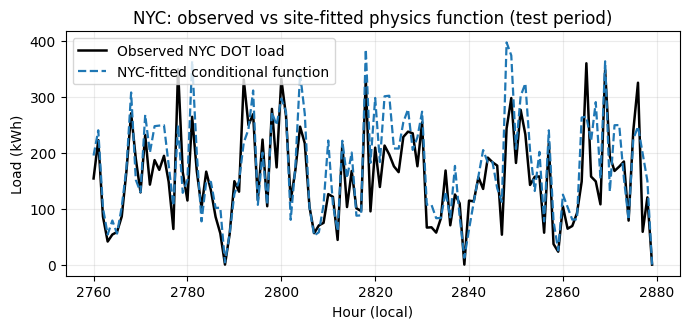

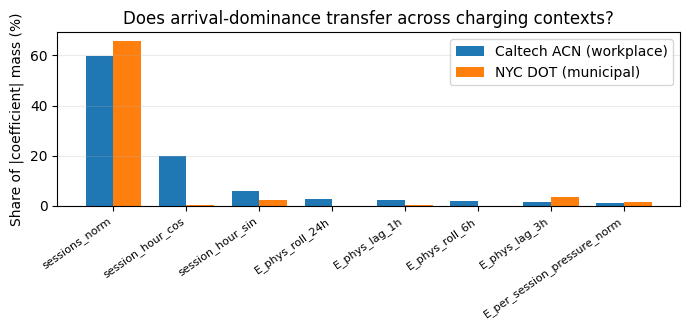

In [43]:
# Figure 1: NYC observed vs site-fitted conditional function (test period)
m, feats = models_nyc["nyc_conditional"]
pred_all = np.clip(m.predict(h_nyc_fit[feats].values), 0, None)
sub = h_nyc_fit[te_nyc].head(24*5)
t = sub["day"]*24 + sub["hour"]
fig, ax = plt.subplots(figsize=(7.0,3.4))
ax.plot(t, sub["real_load_kwh"], "k-", lw=1.8, label="Observed NYC DOT load")
ax.plot(t, pred_all[sub.index], "--", lw=1.6, label="NYC-fitted conditional function")
ax.set_xlabel("Hour (local)"); ax.set_ylabel("Load (kWh)")
ax.set_title("NYC: observed vs site-fitted physics function (test period)")
ax.legend(); ax.grid(alpha=.25); fig.tight_layout()
fig.savefig("figures_p2/fig1_nyc_calibration.png", dpi=400)
fig.savefig("figures_p2/fig1_nyc_calibration.pdf"); plt.show()

# Figure 2: coefficient-share bars, both sites
top = comp.head(8)
x = np.arange(len(top)); w = 0.38
fig, ax = plt.subplots(figsize=(7.0,3.4))
ax.bar(x-w/2, top["share_pct_caltech"], w, label="Caltech ACN (workplace)")
ax.bar(x+w/2, top["share_pct_nyc"], w, label="NYC DOT (municipal)")
ax.set_xticks(x); ax.set_xticklabels(top.index, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("Share of |coefficient| mass (%)")
ax.set_title("Does arrival-dominance transfer across charging contexts?")
ax.legend(); ax.grid(axis="y", alpha=.25); fig.tight_layout()
fig.savefig("figures_p2/fig2_coefficient_transfer.png", dpi=400)
fig.savefig("figures_p2/fig2_coefficient_transfer.pdf"); plt.show()

In [44]:
print(list(src.columns))
timeish = [c for c in src.columns if any(k in c.lower() for k in ("time","date","start","began"))]
print(src[timeish].head(10).to_string())

['date', 'station_name', 'location_name', 'country', 'charge_box_id', 'connector_id', 'driver_id', 'id_tag', 'connected_time', 'disconnected_time', 'charge_duration_min', 'connected_duration_min', 'energy_provided_kwh', 'session_status', 'invalidity_reason', 'ts_local', 'timestamp_hour']
                       date connected_time disconnected_time            timestamp_hour
34  2026-07-02T00:00:00.000       03:30:22          04:16:05 2026-07-02 03:00:00-04:00
35  2026-07-02T00:00:00.000       00:42:38          01:21:28 2026-07-02 00:00:00-04:00
36  2026-07-02T00:00:00.000       02:50:03          03:09:59 2026-07-02 02:00:00-04:00
37  2026-07-02T00:00:00.000       03:10:49          03:24:08 2026-07-02 03:00:00-04:00
38  2026-07-02T00:00:00.000       01:22:45          01:38:44 2026-07-02 01:00:00-04:00
39  2026-07-02T00:00:00.000       01:39:14          01:47:24 2026-07-02 01:00:00-04:00
40  2026-07-02T00:00:00.000       01:47:46          01:51:32 2026-07-02 01:00:00-04:00
41  2026-07-02T

## Done — outputs map to Manuscript 2

| Output | Manuscript 2 element |
|---|---|
| `results_p2/physics_function_metrics_nyc.csv` | Table 1 (NYC calibration) |
| `results_p2/table2_coefficient_comparison.csv` + fig2 | Table 2 + Figure 2 (headline) |
| `results_p2/table3_cross_site_transfer.csv` | Table 3 (frozen-model transfer) |
| `results_p2/physics_function_metrics_caltech_local.csv` | Methods note: local-time refit consistency check |
| JPL/office outputs (Section 7) | Optional 4-site extension table |

**Interpretation rule (prespecified):** if arrival terms dominate at both sites AND R²_shape materially exceeds R²_raw → "structure transfers; magnitudes are site-specific." If NYC is not arrival-dominated → "calibration is population-dependent" — equally publishable; do not force the first story.

**Report honestly:** NYC observation-window length; the flat-E_phys fallback if used; that user populations (workplace vs municipal) co-vary with site.

## 9. Revision experiments (reviewer-requested)

Run AFTER Sections 3, 5, 6, 7 in the same kernel. Produces:
- **Table 4:** day-block bootstrap CIs on arrival-related coefficient share, per site
- **Table 5:** flat-prior sensitivity — arrival share at Caltech/JPL refit with a FLAT driving-energy prior (matches NYC's construction, so the three sites are prior-identical)
- **Figure 3:** data-efficiency curve — how many local NYC days recover the full-window R²
- **Figures 4–5:** three-site coefficient shares; three-site mean daily load profiles

In [46]:
# --- 9.1 Day-block bootstrap CIs on the arrival-related coefficient share (fixed) ---
ARR = ["sessions_norm", "session_hour_sin", "session_hour_cos"]
import os as _os
_os.makedirs("results_p2/_tmp", exist_ok=True)

def arrival_share_once(h, n_train_days, day_sample=None):
    if day_sample is None:
        hh = h
    else:
        # each sampled day becomes its OWN block, even if drawn twice
        blocks = []
        for j, dsel in enumerate(day_sample):
            b = h[h["day"] == dsel].copy()
            b["day"] = j
            blocks.append(b)
        hh = pd.concat(blocks, ignore_index=True)
    _, _, _, _, _, cdf = fit_physics_function(hh, n_train_days, "_boot",
                                              results_dir="results_p2/_tmp")
    d = cdf[(cdf.model == "_boot_conditional") & (cdf.feature != "intercept")]
    return 100 * d[d.feature.isin(ARR)].coefficient.abs().sum() / d.coefficient.abs().sum()

rng_b = np.random.default_rng(SEED)
N_BOOT = 200
rows = []
for site, h, ntr in [("caltech", h_cal_fit, h_cal_fit["day"].nunique() - CAL_TEST),
                     ("jpl", extra_results["jpl"][0], extra_results["jpl"][0]["day"].nunique()
                        - max(7, int(round(extra_results["jpl"][0]["day"].nunique() * 0.2)))),
                     ("nyc", h_nyc_fit, n_days_nyc - NYC_TEST_DAYS)]:
    hb = h[["day","hour","dow","is_weekend","real_load_kwh","n_sessions","E_phys_raw_kwh"]].copy()
    days = sorted(hb["day"].unique())
    point = arrival_share_once(hb, ntr)
    boots, first_err = [], None
    for _ in range(N_BOOT):
        samp = list(rng_b.choice(days, size=len(days), replace=True))
        try:
            boots.append(arrival_share_once(hb, ntr, day_sample=samp))
        except Exception as e:
            if first_err is None: first_err = repr(e)
    if len(boots) < N_BOOT * 0.9:
        raise RuntimeError(f"{site}: only {len(boots)}/{N_BOOT} bootstrap fits succeeded. "
                           f"First error: {first_err}")
    lo, hi = np.percentile(boots, [2.5, 97.5])
    rows.append({"site": site, "arrival_share_pct": round(point, 1),
                 "boot_CI95_lo": round(lo, 1), "boot_CI95_hi": round(hi, 1),
                 "n_boot": len(boots)})
    print(rows[-1])
boot_df = pd.DataFrame(rows)
boot_df.to_csv("results_p2/table4_bootstrap_arrival_share.csv", index=False)
display(boot_df)

{'site': 'caltech', 'arrival_share_pct': np.float64(85.7), 'boot_CI95_lo': np.float64(66.2), 'boot_CI95_hi': np.float64(89.0), 'n_boot': 200}
{'site': 'jpl', 'arrival_share_pct': np.float64(83.5), 'boot_CI95_lo': np.float64(81.0), 'boot_CI95_hi': np.float64(91.6), 'n_boot': 200}
{'site': 'nyc', 'arrival_share_pct': np.float64(68.3), 'boot_CI95_lo': np.float64(62.6), 'boot_CI95_hi': np.float64(87.3), 'n_boot': 200}


,site,arrival_share_pct,boot_CI95_lo,boot_CI95_hi,n_boot
0,caltech,85.7,66.2,89.0,200
1,jpl,83.5,81.0,91.6,200
2,nyc,68.3,62.6,87.3,200


In [47]:
# --- 9.2 Flat-prior sensitivity: refit Caltech & JPL with FLAT E_phys (prior-identical to NYC) ---
rows = []
for site, h, ntr in [("caltech", h_cal_fit, h_cal_fit["day"].nunique() - CAL_TEST),
                     ("jpl", extra_results["jpl"][0], extra_results["jpl"][0]["day"].nunique()
                        - max(7, int(round(extra_results["jpl"][0]["day"].nunique() * 0.2))))]:
    hb = h[["day","hour","dow","is_weekend","real_load_kwh","n_sessions"]].copy()
    hb["E_phys_raw_kwh"] = 1.0
    _, _, _, tem_f, mdf, cdf = fit_physics_function(hb, ntr, f"{site}_flatprior", results_dir="results_p2")
    d = cdf[(cdf.model == f"{site}_flatprior_conditional") & (cdf.feature != "intercept")]
    arr = 100 * d[d.feature.isin(ARR)].coefficient.abs().sum() / d.coefficient.abs().sum()
    r2t = mdf[(mdf.model == f"{site}_flatprior_conditional") & (mdf.split == "test")].R2.iloc[0]
    rows.append({"site": site, "arrival_share_flat_prior_pct": round(arr, 1),
                 "test_R2_flat_prior": round(r2t, 3)})
    print(rows[-1])
flat_df = pd.DataFrame(rows)
flat_df.to_csv("results_p2/table5_flat_prior_sensitivity.csv", index=False)
print("\nIf these shares stay near the with-prior values (85.7 / 83.5), arrival-dominance")
print("is NOT an artifact of prior construction, and the three sites are comparable.")

{'site': 'caltech', 'arrival_share_flat_prior_pct': np.float64(95.9), 'test_R2_flat_prior': np.float64(0.814)}
{'site': 'jpl', 'arrival_share_flat_prior_pct': np.float64(94.3), 'test_R2_flat_prior': np.float64(0.962)}

If these shares stay near the with-prior values (85.7 / 83.5), arrival-dominance
is NOT an artifact of prior construction, and the three sites are comparable.


{'local_train_days': 14, 'test_R2': np.float64(0.5219142782645787)}
{'local_train_days': 28, 'test_R2': np.float64(0.5232325860559395)}
{'local_train_days': 56, 'test_R2': np.float64(0.508353968059204)}
{'local_train_days': 84, 'test_R2': np.float64(0.48150975449491673)}
{'local_train_days': 112, 'test_R2': np.float64(0.405262333479007)}
{'local_train_days': 115, 'test_R2': np.float64(0.39924220612822836)}


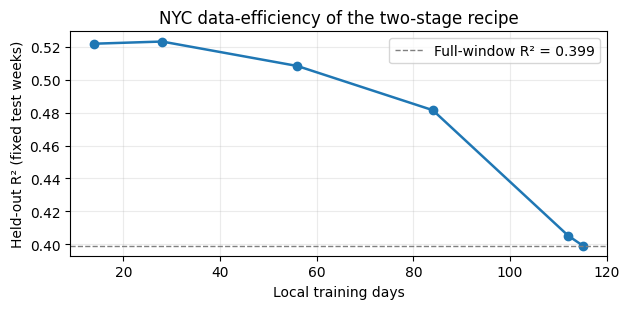

In [48]:
# --- 9.3 Data-efficiency: how many local NYC days recover full-window skill? (Figure 3) ---
test_days_fixed = sorted(h_nyc_fit["day"].unique())[-NYC_TEST_DAYS:]
h_test = h_nyc_fit[h_nyc_fit["day"].isin(test_days_fixed)]
full_r2 = None
rows = []
for k in [14, 28, 56, 84, 112, n_days_nyc - NYC_TEST_DAYS]:
    train_days_k = sorted(h_nyc_fit["day"].unique())[-NYC_TEST_DAYS - k:-NYC_TEST_DAYS]
    hb = h_nyc_fit[h_nyc_fit["day"].isin(list(train_days_k) + test_days_fixed)][
        ["day","hour","dow","is_weekend","real_load_kwh","n_sessions","E_phys_raw_kwh"]].copy()
    hb = hb.assign(day=hb.groupby("day", sort=True).ngroup())
    _, _, _, _, mdf, _ = fit_physics_function(hb, k, f"nyc_k{k}", results_dir="results_p2/_tmp")
    r2 = mdf[(mdf.model == f"nyc_k{k}_conditional") & (mdf.split == "test")].R2.iloc[0]
    rows.append({"local_train_days": k, "test_R2": r2})
    print(rows[-1])
eff = pd.DataFrame(rows)
full_r2 = eff.test_R2.iloc[-1]
eff["pct_of_full_R2"] = (100 * eff.test_R2 / full_r2).round(1)
eff.to_csv("results_p2/table6_data_efficiency.csv", index=False)

fig, ax = plt.subplots(figsize=(6.4, 3.2))
ax.plot(eff.local_train_days, eff.test_R2, "o-", lw=1.8)
ax.axhline(full_r2, ls="--", c="gray", lw=1, label=f"Full-window R² = {full_r2:.3f}")
ax.set_xlabel("Local training days"); ax.set_ylabel("Held-out R² (fixed test weeks)")
ax.set_title("NYC data-efficiency of the two-stage recipe")
ax.legend(); ax.grid(alpha=.25); fig.tight_layout()
fig.savefig("figures_p2/fig3_data_efficiency.png", dpi=500)
fig.savefig("figures_p2/fig3_data_efficiency.pdf"); plt.show()

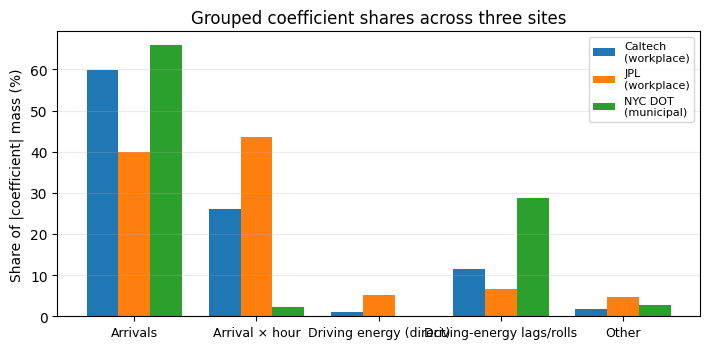

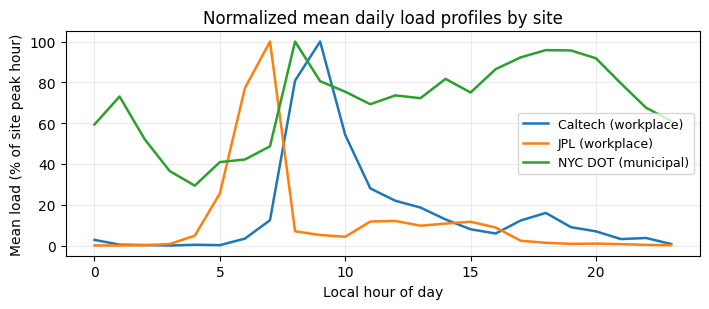

In [49]:
# --- 9.4 Publication figures: three-site shares (Fig 4) and daily profiles (Fig 5) ---
def shares_of(cdf, model):
    d = cdf[(cdf.model == model) & (cdf.feature != "intercept")].copy()
    d["share"] = 100 * d.coefficient.abs() / d.coefficient.abs().sum()
    return d.set_index("feature")["share"]

S = {"Caltech\n(workplace)": shares_of(c_cal, "caltech_local_conditional"),
     "JPL\n(workplace)": shares_of(extra_results["jpl"][5], "jpl_conditional"),
     "NYC DOT\n(municipal)": shares_of(c_nyc, "nyc_conditional")}
groups = {"Arrivals": ["sessions_norm"],
          "Arrival \u00d7 hour": ["session_hour_sin", "session_hour_cos"],
          "Driving energy (direct)": ["E_phys_norm"],
          "Driving-energy lags/rolls": [f"E_phys_lag_{l}h" for l in [1,2,3,6,12,24]] + [f"E_phys_roll_{w}h" for w in [3,6,24]],
          "Other": ["E_per_session_pressure_norm", "hour_sin", "hour_cos", "is_weekend"]}
mat = pd.DataFrame({s: {g: sh.reindex(f).fillna(0).sum() for g, f in groups.items()} for s, sh in S.items()})
x = np.arange(len(groups)); w = 0.26
fig, ax = plt.subplots(figsize=(7.2, 3.6))
for j, sname in enumerate(mat.columns):
    ax.bar(x + (j - 1) * w, mat[sname].values, w, label=sname)
ax.set_xticks(x); ax.set_xticklabels(groups.keys(), fontsize=9)
ax.set_ylabel("Share of |coefficient| mass (%)")
ax.set_title("Grouped coefficient shares across three sites")
ax.legend(fontsize=8); ax.grid(axis="y", alpha=.25); fig.tight_layout()
fig.savefig("figures_p2/fig4_three_site_shares.png", dpi=500)
fig.savefig("figures_p2/fig4_three_site_shares.pdf"); plt.show()

fig, ax = plt.subplots(figsize=(7.2, 3.2))
for name, h in [("Caltech (workplace)", h_cal_fit), ("JPL (workplace)", extra_results["jpl"][0]),
                ("NYC DOT (municipal)", h_nyc_fit)]:
    prof = h.groupby("hour")["real_load_kwh"].mean()
    ax.plot(prof.index, 100 * prof / prof.max(), lw=1.8, label=name)
ax.set_xlabel("Local hour of day"); ax.set_ylabel("Mean load (% of site peak hour)")
ax.set_title("Normalized mean daily load profiles by site")
ax.legend(fontsize=9); ax.grid(alpha=.25); fig.tight_layout()
fig.savefig("figures_p2/fig5_daily_profiles.png", dpi=500)
fig.savefig("figures_p2/fig5_daily_profiles.pdf"); plt.show()

### 9.5 Workplace recency sweep (mechanism check)

If Caltech/JPL accuracy is stable or improves with longer windows while NYC declines, non-stationarity — not a generic recency effect — is confirmed as the mechanism behind Section 3.4.

{'site': 'caltech', 'train_days': 14, 'test_R2': 0.822}
{'site': 'caltech', 'train_days': 28, 'test_R2': 0.833}
{'site': 'caltech', 'train_days': 56, 'test_R2': 0.823}
{'site': 'caltech', 'train_days': 84, 'test_R2': 0.821}
{'site': 'caltech', 'train_days': 112, 'test_R2': 0.814}
{'site': 'caltech', 'train_days': 115, 'test_R2': 0.816}
{'site': 'jpl', 'train_days': 14, 'test_R2': 0.963}
{'site': 'jpl', 'train_days': 28, 'test_R2': 0.964}
{'site': 'jpl', 'train_days': 56, 'test_R2': 0.963}
{'site': 'jpl', 'train_days': 84, 'test_R2': 0.962}
{'site': 'jpl', 'train_days': 112, 'test_R2': 0.962}
{'site': 'jpl', 'train_days': 115, 'test_R2': 0.963}
{'site': 'nyc', 'train_days': 14, 'test_R2': 0.522}
{'site': 'nyc', 'train_days': 28, 'test_R2': 0.523}
{'site': 'nyc', 'train_days': 56, 'test_R2': 0.508}
{'site': 'nyc', 'train_days': 84, 'test_R2': 0.482}
{'site': 'nyc', 'train_days': 112, 'test_R2': 0.405}
{'site': 'nyc', 'train_days': 115, 'test_R2': 0.399}


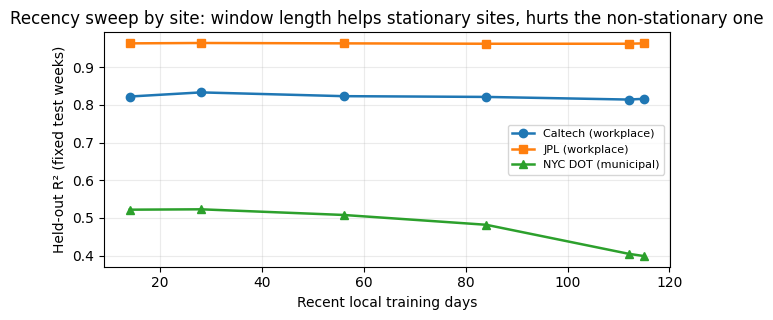


Expected pattern: flat/rising curves at Caltech & JPL; declining at NYC.


In [50]:
# --- 9.5 Recency sweep at ALL sites: stationary vs non-stationary mechanism ---
def recency_sweep(h, test_days_n, label):
    days = sorted(h["day"].unique())
    test_days_fixed = days[-test_days_n:]
    rows = []
    ks = [14, 28, 56, 84, 112]
    ks = [k for k in ks if k <= len(days) - test_days_n] + [len(days) - test_days_n]
    for k in sorted(set(ks)):
        train_k = days[-test_days_n - k:-test_days_n]
        hb = h[h["day"].isin(list(train_k) + test_days_fixed)][
            ["day","hour","dow","is_weekend","real_load_kwh","n_sessions","E_phys_raw_kwh"]].copy()
        hb = hb.assign(day=hb.groupby("day", sort=True).ngroup())
        _, _, _, _, mdf, _ = fit_physics_function(hb, k, f"{label}_k{k}", results_dir="results_p2/_tmp")
        r2 = mdf[(mdf.model == f"{label}_k{k}_conditional") & (mdf.split == "test")].R2.iloc[0]
        rows.append({"site": label, "train_days": k, "test_R2": round(float(r2), 3)})
        print(rows[-1])
    return pd.DataFrame(rows)

sweep = pd.concat([
    recency_sweep(h_cal_fit, CAL_TEST, "caltech"),
    recency_sweep(extra_results["jpl"][0],
                  max(7, int(round(extra_results["jpl"][0]["day"].nunique()*0.2))), "jpl"),
    recency_sweep(h_nyc_fit, NYC_TEST_DAYS, "nyc"),
], ignore_index=True)
sweep.to_csv("results_p2/table7_recency_sweep_all_sites.csv", index=False)

fig, ax = plt.subplots(figsize=(6.6, 3.3))
for site, marker in [("caltech","o"), ("jpl","s"), ("nyc","^")]:
    d = sweep[sweep.site==site]
    ax.plot(d.train_days, d.test_R2, marker+"-", lw=1.8,
            label={"caltech":"Caltech (workplace)","jpl":"JPL (workplace)","nyc":"NYC DOT (municipal)"}[site])
ax.set_xlabel("Recent local training days"); ax.set_ylabel("Held-out R\u00b2 (fixed test weeks)")
ax.set_title("Recency sweep by site: window length helps stationary sites, hurts the non-stationary one")
ax.legend(fontsize=8); ax.grid(alpha=.25); fig.tight_layout()
fig.savefig("figures_p2/fig4b_recency_all_sites.png", dpi=500)
fig.savefig("figures_p2/fig4b_recency_all_sites.pdf"); plt.show()
print("\nExpected pattern: flat/rising curves at Caltech & JPL; declining at NYC.")